# DeepCoder Pipeline – Schritt für Schritt

Dieses Notebook orchestriert `deepcoder_pipeline/scripts/` genau wie
`run_all.sh`, aber Zelle für Zelle — so wie
`DreamCoder_Train_Test_Workflow.ipynb` (`dreamcoder_train_test_pipeline_step_by_step`)
die DreamCoder-Pipeline Schritt für Schritt ausführt. Jeder Schritt läuft als
eigener Subprozess, sein Output wird live angezeigt und in `output/logs/`
protokolliert. Danach kannst du die erzeugten Dateien direkt im Notebook
prüfen, bevor du weitergehst.

Muss im Ordner `deepcoder_pipeline/` liegen und mit dem Kernel des
`deepcoder`-`.venv` (Python 3.9, TensorFlow/Keras 2.12) ausgeführt werden.


In [1]:
from pathlib import Path
import os, sys, subprocess, json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
print("Aktueller Ordner:", ROOT)
print("Dateien:", sorted(p.name for p in ROOT.iterdir()))

assert (ROOT / "scripts").exists(), "Der Ordner scripts fehlt. Notebook im deepcoder_pipeline-Ordner ausführen."


Aktueller Ordner: C:\BA\deepcoder\deepcoder_pipeline
Dateien: ['README.md', 'deepcoder_metric_analysis.ipynb', 'output', 'run_all.sh', 'scripts']


## 0. Konfiguration

Hier stellst du ein, welcher Datensatz (`T`), welches Suchbudget (`gas`) und wie viele Trainingsepochen benutzt werden.

In [2]:
T = int(os.environ.get("T", 2))
GAS = int(os.environ.get("GAS", 1000))
EPOCHS = int(os.environ.get("EPOCHS", 10))
SEED = int(os.environ.get("SEED", 42))  # fester Seed fuer reproduzierbares Training (siehe train-nn.py)

PYTHON = sys.executable
DEEPCODER_REPO_ROOT = ROOT.parent
TRAIN_PATH = DEEPCODER_REPO_ROOT / "dataset" / f"T={T}_train.json"
TEST_PATH = DEEPCODER_REPO_ROOT / "dataset" / f"T={T}_test.json"

# Ein eigener Run-Ordner pro Hyperparameter-Kombination (gleiches Schema wie
# run_all.sh) - nichts wird zwischen unterschiedlichen T/GAS/EPOCHS/SEED
# ueberschrieben, und jeder Schritt bekommt seine eigene Datei/Log darin.
OUTPUT_DIR = ROOT / "output"
RUN_DIR = OUTPUT_DIR / "runs" / f"T{T}_gas{GAS}_epochs{EPOCHS}_seed{SEED}"
LOG_DIR = RUN_DIR / "logs"
RUN_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(exist_ok=True)

ENV = os.environ.copy()
ENV["PYTHONPATH"] = str(DEEPCODER_REPO_ROOT)

NO_PRED_H5 = RUN_DIR / "solve_no_predictor.h5"
NO_PRED_CSV = RUN_DIR / "solve_no_predictor.csv"
NO_PRED_METRICS = RUN_DIR / "metrics_no_predictor.csv"
WITH_PRED_H5 = RUN_DIR / "solve_with_predictor.h5"
WITH_PRED_CSV = RUN_DIR / "solve_with_predictor.csv"
WITH_PRED_METRICS = RUN_DIR / "metrics_with_predictor.csv"
MODEL_FILE = RUN_DIR / "model.h5"

print("PYTHON:", PYTHON)
print("DEEPCODER_REPO_ROOT:", DEEPCODER_REPO_ROOT)
print("T:", T, " GAS:", GAS, " EPOCHS:", EPOCHS, " SEED:", SEED)
print("RUN_DIR:", RUN_DIR)
print("TRAIN_PATH:", TRAIN_PATH, TRAIN_PATH.exists())
print("TEST_PATH:", TEST_PATH, TEST_PATH.exists())

assert TRAIN_PATH.exists(), "Trainingsdatensatz fehlt."
assert TEST_PATH.exists(), "Testdatensatz fehlt."


PYTHON: C:\BA\deepcoder\.venv\Scripts\python.exe
DEEPCODER_REPO_ROOT: C:\BA\deepcoder
T: 2  GAS: 1000  EPOCHS: 10  SEED: 42
RUN_DIR: C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42
TRAIN_PATH: C:\BA\deepcoder\dataset\T=2_train.json True
TEST_PATH: C:\BA\deepcoder\dataset\T=2_test.json True


## Hilfsfunktion zum Ausführen eines Schritts

Streamt den Output eines Pipeline-Skripts live ins Notebook und schreibt ihn zusätzlich nach `output/logs/`.

In [3]:
def run_step(name, cmd, log_name=None):
    log_name = log_name or f"{name}.log"
    log_path = LOG_DIR / log_name
    print("\n" + "=" * 80)
    print(name)
    print("Command:", " ".join(map(str, cmd)))
    print("Log:", log_path)
    print("=" * 80 + "\n")
    with open(log_path, "w", encoding="utf-8") as f:
        process = subprocess.Popen(
            list(map(str, cmd)),
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            encoding="utf-8",
            errors="replace",
            bufsize=1,
            env=ENV,
        )
        for line in process.stdout:
            print(line, end="")
            f.write(line)
        rc = process.wait()
    print("\nReturn code:", rc)
    if rc != 0:
        raise RuntimeError(f"{name} failed with return code {rc}")
    return log_path


## Schritt 1 – DFS-Solver ohne Prädiktor (Baseline)

Reine Brute-Force-DFS-Suche mit Budget `gas`, ohne neuronales Netz.

Ergebnis: `RUN_DIR/solve_no_predictor.h5`

In [4]:
run_step("step1_solve_no_predictor", [
    PYTHON, ROOT / "scripts" / "solve-problems.py",
    TEST_PATH, "--T", T, "--mode", "dfs", "--gas", GAS,
    "--outfile", NO_PRED_H5,
])

df_no_pred = pd.read_hdf(NO_PRED_H5, "data")
print("Gelöst:", int(df_no_pred["solution"].notna().sum()), "/", len(df_no_pred))
df_no_pred.head(10)



step1_solve_no_predictor
Command: C:\BA\deepcoder\.venv\Scripts\python.exe C:\BA\deepcoder\deepcoder_pipeline\scripts\solve-problems.py C:\BA\deepcoder\dataset\T=2_test.json --T 2 --mode dfs --gas 1000 --outfile C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\solve_no_predictor.h5
Log: C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\logs\step1_solve_no_predictor.log



  1%|          | 1/100 [00:04<07:50,  4.76s/it]


 17%|█▋        | 17/100 [00:04<00:14,  5.83it/s]


 30%|███       | 30/100 [00:05<00:05, 11.67it/s]


 41%|████      | 41/100 [00:05<00:03, 18.14it/s]


...

100%|██████████| 100/100 [00:07<00:00, 13.70it/s]
C:\BA\deepcoder\deepcoder_pipeline\scripts\solve-problems.py:104: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  df.to_hdf(args.outfile, 'data')


C:\BA\deepcoder\deepcoder_pipeline\scripts\solve-problems.py:104: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block2_values] [items->Index(['solution', 'reference', 'best_partial_solution'], dtype='object')]

  df.to_hdf(args.outfile, 'data')
summary:
solved 53/100 (53.0%)
          nb_steps     wall_ms  best_partial_match_fraction
count   100.000000  100.000000                    47.000000
mean    628.420000   70.091476                     0.187234
std     412.020181   48.958685                     0.233701
min       1.000000    0.000000                     0.000000
25%     175.500000   16.544878                     0.000000
50%     830.000000   82.445621                     0.200000
75%    1000.000000  114.653051                     0.200000
max    1002.000000  152.089119                     0.800000
of 47 unsolved tasks, 25 have a best-partial candidate (mean match fraction 0.


Return code: 0


Gelöst: 53 / 100


,nb_steps,wall_ms,solution,reference,best_partial_solution,best_partial_match_fraction
0,1000,86.112261,None,"LIST|COUNT,<0,0|TAKE,1,0","LIST|FILTER,<0,0|ZIPWITH,max,1,0",0.4
1,1000,132.854700,None,"LIST|FILTER,<0,0|ZIPWITH,*,0,1","LIST|HEAD,0|DROP,1,0",0.4
2,1000,152.089119,None,"LIST|FILTER,<0,0|ZIPWITH,*,1,1",None,0.0
3,590,58.073044,"LIST|MAP,*-1,0|FILTER,<0,1","LIST|FILTER,>0,0|MAP,*-1,1",None,NaN
4,835,99.427462,"LIST|FILTER,>0,0|TAIL,1","LIST|FILTER,>0,0|TAIL,1",None,NaN
5,354,29.187441,"LIST|MAP,+1,0|FILTER,ODD,1","LIST|FILTER,EVEN,0|MAP,+1,1",None,NaN
6,842,100.236177,"LIST|FILTER,>0,0|COUNT,ODD,1","LIST|FILTER,ODD,0|COUNT,>0,1",None,NaN
7,1000,112.827063,None,"LIST|FILTER,ODD,0|MAP,*4,1",None,0.0
8,1,0.000000,LIST|INT,"LIST|INT|MAP,/3,0|ACCESS,1,2",None,NaN
9,437,46.721220,"LIST|INT|TAKE,1,0|SCAN1L,-,2","LIST|INT|SCAN1L,-,0|TAKE,1,2",None,NaN


## Schritt 2 – Prädiktor trainieren

Trainiert das neuronale Netz (`sigmoid` + `binary_crossentropy`, siehe README) auf dem Trainingsset. `--seed` macht Gewichtsinitialisierung und Training reproduzierbar — ohne festen Seed variiert die Accuracy nach dem Training von Lauf zu Lauf (beobachtet: 66-73% bei sonst identischer Konfiguration).

Ergebnis: `RUN_DIR/model.h5`

In [5]:
run_step("step2_train_nn", [
    PYTHON, ROOT / "scripts" / "train-nn.py",
    "--in", TRAIN_PATH, "--out", MODEL_FILE, "--epochs", EPOCHS, "--seed", SEED,
])



step2_train_nn
Command: C:\BA\deepcoder\.venv\Scripts\python.exe C:\BA\deepcoder\deepcoder_pipeline\scripts\train-nn.py --in C:\BA\deepcoder\dataset\T=2_train.json --out C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\model.h5 --epochs 10 --seed 42
Log: C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\logs\step2_train_nn.log



Epoch 1/10



 8/74 [==>...........................] - ETA: 1s - loss: 0.5082


23/74 [========>.....................] - ETA: 0s - loss: 0.3554


39/74 [==============>...............] - ETA: 0s - loss: 0.3147


...

68/74 [==========================>...] - ETA: 0s - loss: 0.2537


74/74 [==============================] - 1s 18ms/step - loss: 0.2539


saving model to  C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\model.h5



Return code: 0


WindowsPath('C:/BA/deepcoder/deepcoder_pipeline/output/runs/T2_gas1000_epochs10_seed42/logs/step2_train_nn.log')

## Schritt 3 – DFS-Solver mit Prädiktor

Gleiches Suchbudget `gas` wie in Schritt 1, jetzt mit dem trainierten Netz zur Priorisierung.

Ergebnis: `RUN_DIR/solve_with_predictor.h5`

In [6]:
run_step("step3_solve_with_predictor", [
    PYTHON, ROOT / "scripts" / "solve-problems.py",
    TEST_PATH, "--T", T, "--mode", "dfs", "--gas", GAS,
    "--predictor", MODEL_FILE, "--outfile", WITH_PRED_H5,
])

df_with_pred = pd.read_hdf(WITH_PRED_H5, "data")
print("Gelöst:", int(df_with_pred["solution"].notna().sum()), "/", len(df_with_pred))
df_with_pred.head(10)



step3_solve_with_predictor
Command: C:\BA\deepcoder\.venv\Scripts\python.exe C:\BA\deepcoder\deepcoder_pipeline\scripts\solve-problems.py C:\BA\deepcoder\dataset\T=2_test.json --T 2 --mode dfs --gas 1000 --predictor C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\model.h5 --outfile C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\solve_with_predictor.h5
Log: C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\logs\step3_solve_with_predictor.log




4/4 [==============================] - 3s 12ms/step



  1%|          | 1/100 [00:05<09:40,  5.86s/it]


  8%|▊         | 8/100 [00:06<00:41,  2.20it/s]


 20%|██        | 20/100 [00:06<00:10,  7.46it/s]


...

 81%|████████  | 81/100 [00:07<00:00, 35.04it/s]


100%|██████████| 100/100 [00:08<00:00, 11.17it/s]
C:\BA\deepcoder\deepcoder_pipeline\scripts\solve-problems.py:104: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  df.to_hdf(args.outfile, 'data')


C:\BA\deepcoder\deepcoder_pipeline\scripts\solve-problems.py:104: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block2_values] [items->Index(['solution', 'reference', 'best_partial_solution'], dtype='object')]

  df.to_hdf(args.outfile, 'data')
summary:
solved 65/100 (65.0%)
          nb_steps     wall_ms  best_partial_match_fraction
count   100.000000  100.000000                    35.000000
mean    508.920000   93.375487                     0.188571
std     422.114654   83.483465                     0.227223
min       1.000000    0.000000                     0.000000
25%      62.500000   10.957301                     0.000000
50%     461.000000   71.714520                     0.200000
75%    1000.000000  162.682950                     0.200000
max    1007.000000  340.485811                     0.800000
of 35 unsolved tasks, 20 have a best-partial candidate (mean match fraction 0.


Return code: 0
Gelöst: 65 / 100


,nb_steps,wall_ms,solution,reference,best_partial_solution,best_partial_match_fraction
0,1007,131.991863,None,"LIST|COUNT,<0,0|TAKE,1,0","LIST|FILTER,<0,0|ZIPWITH,max,1,0",0.4
1,1000,171.813488,None,"LIST|FILTER,<0,0|ZIPWITH,*,0,1","LIST|ZIPWITH,*,0,0|FILTER,<0,1",0.4
2,1000,216.601610,None,"LIST|FILTER,<0,0|ZIPWITH,*,1,1",None,0.0
3,534,64.047098,"LIST|MAP,*-1,0|FILTER,<0,1","LIST|FILTER,>0,0|MAP,*-1,1",None,NaN
4,954,150.006533,"LIST|FILTER,>0,0|TAIL,1","LIST|FILTER,>0,0|TAIL,1",None,NaN
5,458,83.290100,"LIST|MAP,+1,0|FILTER,ODD,1","LIST|FILTER,EVEN,0|MAP,+1,1",None,NaN
6,946,154.341698,"LIST|FILTER,>0,0|COUNT,ODD,1","LIST|FILTER,ODD,0|COUNT,>0,1",None,NaN
7,1001,205.293894,None,"LIST|FILTER,ODD,0|MAP,*4,1",None,0.0
8,1,0.000000,LIST|INT,"LIST|INT|MAP,/3,0|ACCESS,1,2",None,NaN
9,1000,234.626770,None,"LIST|INT|SCAN1L,-,0|TAKE,1,2","LIST|INT|ZIPWITH,*,0,0|SCAN1L,-,0",0.8


## Schritt 4 – Ergebnisse nach CSV exportieren

In [7]:
run_step("step4a_export_no_predictor", [
    PYTHON, ROOT / "scripts" / "export_results_to_csv.py",
    "--infile", NO_PRED_H5, "--outfile", NO_PRED_CSV,
])
run_step("step4b_export_with_predictor", [
    PYTHON, ROOT / "scripts" / "export_results_to_csv.py",
    "--infile", WITH_PRED_H5, "--outfile", WITH_PRED_CSV,
])



step4a_export_no_predictor
Command: C:\BA\deepcoder\.venv\Scripts\python.exe C:\BA\deepcoder\deepcoder_pipeline\scripts\export_results_to_csv.py --infile C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\solve_no_predictor.h5 --outfile C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\solve_no_predictor.csv
Log: C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\logs\step4a_export_no_predictor.log



Saved 100 rows to C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\solve_no_predictor.csv
                        reference  ... best_partial_match_fraction
0        LIST|COUNT,<0,0|TAKE,1,0  ...                         0.4
1  LIST|FILTER,<0,0|ZIPWITH,*,0,1  ...                         0.4
2  LIST|FILTER,<0,0|ZIPWITH,*,1,1  ...                         0.0
3      LIST|FILTER,>0,0|MAP,*-1,1  ...                         NaN
4         LIST|FILTER,>0,0|TAIL,1  ...                         NaN
5     LIST|FILTER,EVEN,0|MAP,+1,1  ...                         NaN
6    LIST|FILTER,ODD,0|COUNT,>0,1  ...                         NaN
7      LIST|FILTER,ODD,0|MAP,*4,1  ...                         0.0
8    LIST|INT|MAP,/3,0|ACCESS,1,2  ...                         NaN
9    LIST|INT|SCAN1L,-,0|TAKE,1,2  ...                         NaN

[10 rows x 7 columns]

Return code: 0

step4b_export_with_predictor
Command: C:\BA\deepcoder\.venv\Scripts\python.exe C:\BA\deepcoder\deepcoder_pip

Saved 100 rows to C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\solve_with_predictor.csv
                        reference  ... best_partial_match_fraction
0        LIST|COUNT,<0,0|TAKE,1,0  ...                         0.4
1  LIST|FILTER,<0,0|ZIPWITH,*,0,1  ...                         0.4
2  LIST|FILTER,<0,0|ZIPWITH,*,1,1  ...                         0.0
3      LIST|FILTER,>0,0|MAP,*-1,1  ...                         NaN
4         LIST|FILTER,>0,0|TAIL,1  ...                         NaN
5     LIST|FILTER,EVEN,0|MAP,+1,1  ...                         NaN
6    LIST|FILTER,ODD,0|COUNT,>0,1  ...                         NaN
7      LIST|FILTER,ODD,0|MAP,*4,1  ...                         0.0
8    LIST|INT|MAP,/3,0|ACCESS,1,2  ...                         NaN
9    LIST|INT|SCAN1L,-,0|TAKE,1,2  ...                         0.8

[10 rows x 7 columns]

Return code: 0


WindowsPath('C:/BA/deepcoder/deepcoder_pipeline/output/runs/T2_gas1000_epochs10_seed42/logs/step4b_export_with_predictor.log')

## Schritt 5 – Metriken berechnen

`compute_metrics.py` berechnet pro Aufgabe:
- `accuracy` — **exakte** Token-Gleichheit von Referenz- und gefundenem Programm
- `program_operation_score`, `program_position_score`, `program_order_score`, `program_edit_score` — Programm-Ähnlichkeitsmetriken
- `partial_correctness` — gleich gewichteter Durchschnitt der vier Ähnlichkeitsmetriken

Die `solved`-Spalte (aus Schritt 1/3) bleibt zusätzlich erhalten und misst **funktionale** Korrektheit (I/O-Beispiele erfüllt), unabhängig von `accuracy`.


In [8]:
run_step("step5a_compute_metrics_no_predictor", [
    PYTHON, ROOT / "scripts" / "compute_metrics.py",
    "--infile", NO_PRED_CSV, "--outfile", NO_PRED_METRICS,
])
run_step("step5b_compute_metrics_with_predictor", [
    PYTHON, ROOT / "scripts" / "compute_metrics.py",
    "--infile", WITH_PRED_CSV, "--outfile", WITH_PRED_METRICS,
])

metrics_no_pred = pd.read_csv(NO_PRED_METRICS)
metrics_with_pred = pd.read_csv(WITH_PRED_METRICS)

# accuracy (compute_metrics.py) = exaktes Token-Match, streng.
# solved = funktionale Korrektheit (I/O-Beispiele erfüllt), wie in Schritt 1/3.
# Beide als eigene Spalte nebeneinander, damit der Unterschied sichtbar bleibt.
metrics_no_pred["accuracy_functional"] = metrics_no_pred["solved"].astype(float)
metrics_with_pred["accuracy_functional"] = metrics_with_pred["solved"].astype(float)



step5a_compute_metrics_no_predictor
Command: C:\BA\deepcoder\.venv\Scripts\python.exe C:\BA\deepcoder\deepcoder_pipeline\scripts\compute_metrics.py --infile C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\solve_no_predictor.csv --outfile C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\metrics_no_predictor.csv
Log: C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\logs\step5a_compute_metrics_no_predictor.log



Saved 100 rows to C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\metrics_no_predictor.csv

Summary:
         accuracy  ...  best_effort_partial_correctness
count  100.000000  ...                       100.000000
mean     0.110000  ...                         0.414917
std      0.314466  ...                         0.291750
min      0.000000  ...                         0.000000
25%      0.000000  ...                         0.333333
50%      0.000000  ...                         0.416667
75%      0.000000  ...                         0.500000
max      1.000000  ...                         1.000000

[8 rows x 7 columns]

Solved count:
solved
True     53
False    47
Name: count, dtype: int64

Unsolved tasks: 47
  with a best-partial candidate: 25
  mean partial_correctness (old, always 0): 0.0000
  mean best_effort_partial_correctness (new): 0.2556

Return code: 0

step5b_compute_metrics_with_predictor
Command: C:\BA\deepcoder\.venv\Scripts\python.exe C:\BA\deep

Saved 100 rows to C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\metrics_with_predictor.csv

Summary:
         accuracy  ...  best_effort_partial_correctness
count  100.000000  ...                       100.000000
mean     0.190000  ...                         0.501958
std      0.394277  ...                         0.311968
min      0.000000  ...                         0.000000
25%      0.000000  ...                         0.333333
50%      0.000000  ...                         0.500000
75%      0.000000  ...                         0.666667
max      1.000000  ...                         1.000000

[8 rows x 7 columns]

Solved count:
solved
True     65
False    35
Name: count, dtype: int64

Unsolved tasks: 35
  with a best-partial candidate: 20
  mean partial_correctness (old, always 0): 0.0000
  mean best_effort_partial_correctness (new): 0.2637

Return code: 0


## Vergleich: ohne vs. mit Training

`solved_count` = funktional gelöst (I/O-Beispiele erfüllt), als Anzahl. `accuracy_functional` ist dieselbe Größe als Anteil (0-1). `accuracy` ist die strengere Metrik: exaktes Token-Match mit dem Referenzprogramm. Alle anderen Zeilen sind Mittelwerte über die 100 Testaufgaben.

In [9]:
score_columns = [
    "accuracy_functional",
    "accuracy",
    "program_operation_score",
    "program_position_score",
    "program_order_score",
    "program_edit_score",
    "partial_correctness",
]

comparison = pd.DataFrame({
    "ohne Training": [int(metrics_no_pred["solved"].sum())] + list(metrics_no_pred[score_columns].mean().round(4)),
    "mit Training": [int(metrics_with_pred["solved"].sum())] + list(metrics_with_pred[score_columns].mean().round(4)),
}, index=["solved_count"] + score_columns)

comparison


,ohne Training,mit Training
solved_count,53.0000,65.0000
accuracy_functional,0.5300,0.6500
accuracy,0.1100,0.1900
program_operation_score,0.3132,0.4213
program_position_score,0.2920,0.4088
program_order_score,0.2820,0.3997
program_edit_score,0.2920,0.4088
partial_correctness,0.2948,0.4097


## Diagramm: Metriken im Vergleich

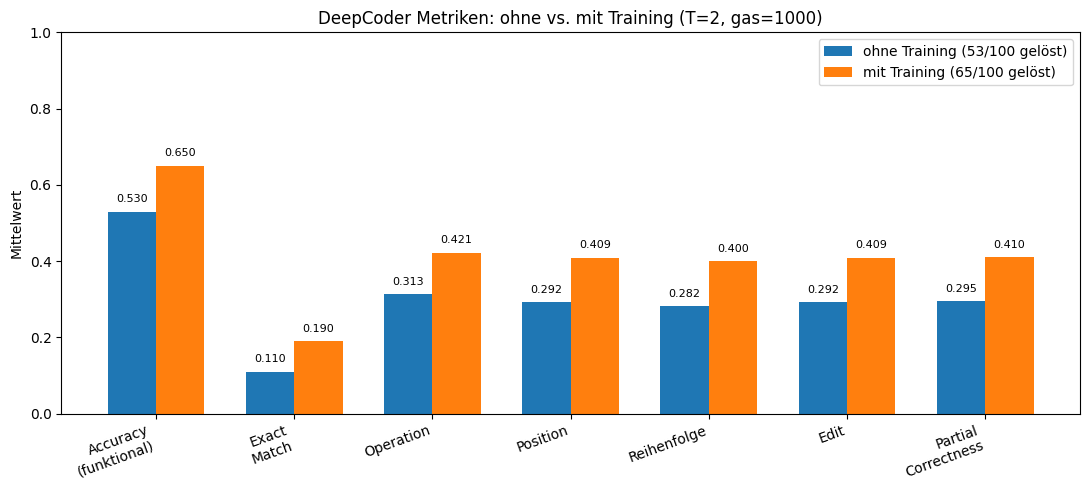

Diagramm gespeichert unter: C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\metric_comparison.png


In [10]:
metrics_plot = [
    "accuracy_functional",
    "accuracy",
    "program_operation_score",
    "program_position_score",
    "program_order_score",
    "program_edit_score",
    "partial_correctness",
]
labels = ["Accuracy\n(funktional)", "Exact\nMatch", "Operation", "Position", "Reihenfolge", "Edit", "Partial\nCorrectness"]

no_pred_vals = metrics_no_pred[metrics_plot].mean().values
with_pred_vals = metrics_with_pred[metrics_plot].mean().values

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
n_solved = int(metrics_no_pred["solved"].sum())
w_solved = int(metrics_with_pred["solved"].sum())
bars1 = ax.bar(x - width / 2, no_pred_vals, width, label=f"ohne Training ({n_solved}/{len(metrics_no_pred)} gelöst)")
bars2 = ax.bar(x + width / 2, with_pred_vals, width, label=f"mit Training ({w_solved}/{len(metrics_with_pred)} gelöst)")

ax.set_ylim(0, 1)
ax.set_ylabel("Mittelwert")
ax.set_title(f"DeepCoder Metriken: ohne vs. mit Training (T={T}, gas={GAS})")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.legend()

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plot_path = RUN_DIR / "metric_comparison.png"
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Diagramm gespeichert unter:", plot_path)


## Diagramm: Nur gelöste Aufgaben (Strukturmetriken)

Wie ähnlich sind gefundene Lösungen dem Referenzprogramm, wenn man nur die tatsächlich gelösten Aufgaben betrachtet?


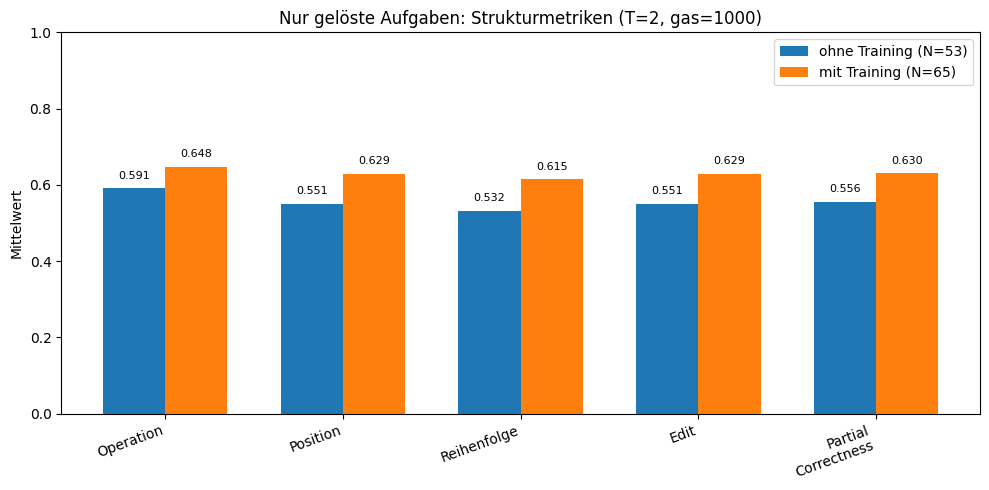

Diagramm gespeichert unter: C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\metric_comparison_solved.png


In [11]:
solved_no_pred = metrics_no_pred[metrics_no_pred["solved"]]
solved_with_pred = metrics_with_pred[metrics_with_pred["solved"]]

metrics_plot_solved = [
    "program_operation_score",
    "program_position_score",
    "program_order_score",
    "program_edit_score",
    "partial_correctness",
]
labels_solved = ["Operation", "Position", "Reihenfolge", "Edit", "Partial\nCorrectness"]

no_pred_vals = solved_no_pred[metrics_plot_solved].mean().values
with_pred_vals = solved_with_pred[metrics_plot_solved].mean().values

x = np.arange(len(labels_solved))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width / 2, no_pred_vals, width, label=f"ohne Training (N={len(solved_no_pred)})")
bars2 = ax.bar(x + width / 2, with_pred_vals, width, label=f"mit Training (N={len(solved_with_pred)})")

ax.set_ylim(0, 1)
ax.set_ylabel("Mittelwert")
ax.set_title(f"Nur gelöste Aufgaben: Strukturmetriken (T={T}, gas={GAS})")
ax.set_xticks(x)
ax.set_xticklabels(labels_solved, rotation=20, ha="right")
ax.legend()

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plot_path_solved = RUN_DIR / "metric_comparison_solved.png"
plt.savefig(plot_path_solved, dpi=200, bbox_inches="tight")
plt.show()

print("Diagramm gespeichert unter:", plot_path_solved)


## Diagramm: Nur ungelöste Aufgaben (Best-Effort-Strukturmetriken)

Für ungelöste Aufgaben speichert die Suche (`deepcoder/search.py`) jetzt zusätzlich das Programm, das die meisten der gegebenen Beispiele erfüllt hat (`best_partial_solution`), auch ohne die Aufgabe vollständig zu lösen. `compute_metrics.py` nutzt dieses Programm für die `best_effort_*`-Spalten, statt die Aufgabe strukturell einfach als "leer" (Score 0) zu behandeln.


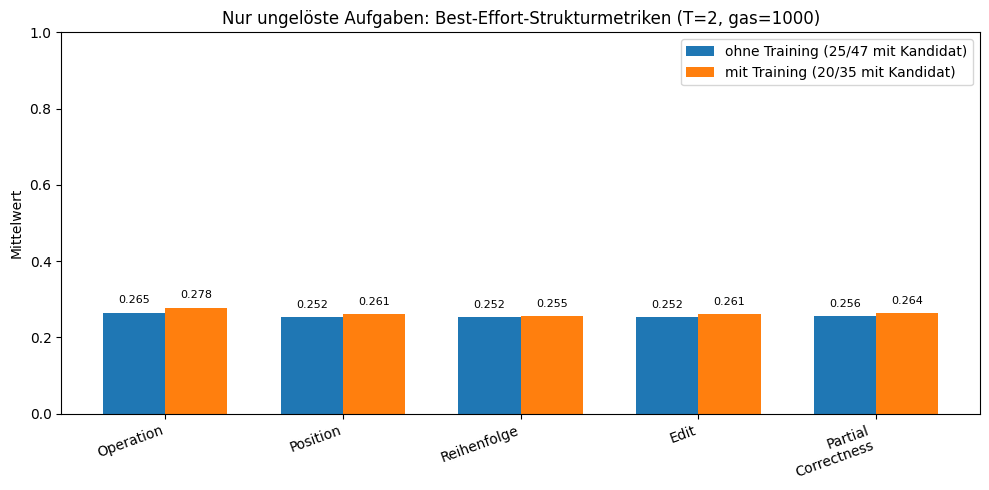

Diagramm gespeichert unter: C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\metric_comparison_unsolved.png

Ohne best_partial_solution waeren alle Werte hier exakt 0 (kein Programm zum Vergleichen).


In [12]:
unsolved_no_pred = metrics_no_pred[~metrics_no_pred["solved"]]
unsolved_with_pred = metrics_with_pred[~metrics_with_pred["solved"]]

metrics_plot_unsolved = [
    "best_effort_operation_score",
    "best_effort_position_score",
    "best_effort_order_score",
    "best_effort_edit_score",
    "best_effort_partial_correctness",
]
labels_unsolved = ["Operation", "Position", "Reihenfolge", "Edit", "Partial\nCorrectness"]

no_pred_vals = unsolved_no_pred[metrics_plot_unsolved].mean().values
with_pred_vals = unsolved_with_pred[metrics_plot_unsolved].mean().values

x = np.arange(len(labels_unsolved))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
n_partial_no = int(unsolved_no_pred["best_effort_program"].notna().sum())
n_partial_with = int(unsolved_with_pred["best_effort_program"].notna().sum())
bars1 = ax.bar(x - width / 2, no_pred_vals, width, label=f"ohne Training ({n_partial_no}/{len(unsolved_no_pred)} mit Kandidat)")
bars2 = ax.bar(x + width / 2, with_pred_vals, width, label=f"mit Training ({n_partial_with}/{len(unsolved_with_pred)} mit Kandidat)")

ax.set_ylim(0, 1)
ax.set_ylabel("Mittelwert")
ax.set_title(f"Nur ungelöste Aufgaben: Best-Effort-Strukturmetriken (T={T}, gas={GAS})")
ax.set_xticks(x)
ax.set_xticklabels(labels_unsolved, rotation=20, ha="right")
ax.legend()

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plot_path_unsolved = RUN_DIR / "metric_comparison_unsolved.png"
plt.savefig(plot_path_unsolved, dpi=200, bbox_inches="tight")
plt.show()

print("Diagramm gespeichert unter:", plot_path_unsolved)
print()
print("Ohne best_partial_solution waeren alle Werte hier exakt 0 (kein Programm zum Vergleichen).")


## Finale Zusammenfassung

In [13]:
summary_lines = [
    "DeepCoder Pipeline Summary",
    "",
    f"T={T}  gas={GAS}  epochs={EPOCHS}  seed={SEED}",
    "",
    f"Ohne Training: {int(metrics_no_pred['solved'].sum())}/{len(metrics_no_pred)} gelöst "
    f"({metrics_no_pred['solved'].mean():.2%}), mean nb_steps={df_no_pred['nb_steps'].mean():.1f}",
    f"Mit Training:  {int(metrics_with_pred['solved'].sum())}/{len(metrics_with_pred)} gelöst "
    f"({metrics_with_pred['solved'].mean():.2%}), mean nb_steps={df_with_pred['nb_steps'].mean():.1f}",
    "",
    "Exakte Programmübereinstimmung (Token-für-Token):",
    f"  ohne Training: {metrics_no_pred['accuracy'].mean():.2%}",
    f"  mit Training:  {metrics_with_pred['accuracy'].mean():.2%}",
    "",
    "Partial Correctness (Mittel aus den 4 Ähnlichkeitsmetriken):",
    f"  ohne Training: {metrics_no_pred['partial_correctness'].mean():.4f}",
    f"  mit Training:  {metrics_with_pred['partial_correctness'].mean():.4f}",
]
summary_text = "\n".join(summary_lines)
print(summary_text)

summary_path = RUN_DIR / "pipeline_summary.txt"
summary_path.write_text(summary_text, encoding="utf-8")
print()
print("Zusammenfassung gespeichert unter:", summary_path)


DeepCoder Pipeline Summary

T=2  gas=1000  epochs=10  seed=42

Ohne Training: 53/100 gelöst (53.00%), mean nb_steps=628.4
Mit Training:  65/100 gelöst (65.00%), mean nb_steps=508.9

Exakte Programmübereinstimmung (Token-für-Token):
  ohne Training: 11.00%
  mit Training:  19.00%

Partial Correctness (Mittel aus den 4 Ähnlichkeitsmetriken):
  ohne Training: 0.2948
  mit Training:  0.4097

Zusammenfassung gespeichert unter: C:\BA\deepcoder\deepcoder_pipeline\output\runs\T2_gas1000_epochs10_seed42\pipeline_summary.txt


## Optional: andere Hyperparameter testen

Ändere oben in der Konfigurationszelle z. B.:

```python
GAS = 1000
```

(oder setze `T`/`GAS`/`EPOCHS`/`SEED` als Umgebungsvariable vor dem Start, genau wie bei `run_all.sh`). Dann Kernel neu starten und alle Zellen von oben nach unten erneut ausführen — die Ergebnisse landen in einem eigenen Run-Ordner (`output/runs/T{T}_gas{GAS}_epochs{EPOCHS}_seed{SEED}/`), ohne andere Kombinationen zu überschreiben.